In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve
from scipy import stats

def analyze_credit_scoring_imbalance(df, target_col='default', threshold=0.1):
    """
    Analyze whether oversampling is needed for credit scoring
    
    Parameters:
    df: DataFrame with credit scoring data
    target_col: name of target variable (default/bad indicator)
    threshold: minimum acceptable bad rate for minority class
    
    Returns:
    dict with analysis results and recommendation
    """
    
    def calculate_metrics(df, target_col):
        """Calculate key metrics for decision making"""
        # Class distribution
        class_dist = df[target_col].value_counts(normalize=True)
        bad_rate = class_dist.get(1, 0)
        
        # Business metrics
        approval_rate = 1 - bad_rate
        
        # Statistical significance
        min_class_size = df[target_col].value_counts().min()
        statistical_power = calculate_statistical_power(min_class_size)
        
        # Feature correlations with target
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        numeric_cols = numeric_cols[numeric_cols != target_col]
        correlations = df[numeric_cols].corrwith(df[target_col]).abs()
        
        return {
            'bad_rate': bad_rate,
            'approval_rate': approval_rate,
            'min_class_size': min_class_size,
            'statistical_power': statistical_power,
            'avg_correlation': correlations.mean(),
            'max_correlation': correlations.max()
        }
    
    def calculate_statistical_power(sample_size, effect_size=0.3, alpha=0.05):
        """Calculate statistical power for given sample size"""
        from scipy.stats import norm
        
        # Simplified power calculation
        z_alpha = norm.ppf(1 - alpha/2)
        z_beta = effect_size * np.sqrt(sample_size) - z_alpha
        power = norm.cdf(z_beta)
        
        return power
    
    def check_oversampling_conditions(metrics, threshold):
        """Check conditions that indicate need for oversampling"""
        conditions = []
        needs_oversampling = False
        
        # Condition 1: Severe class imbalance
        if metrics['bad_rate'] < threshold:
            conditions.append({
                'name': 'Severe class imbalance',
                'status': True,
                'details': f"Bad rate ({metrics['bad_rate']:.1%}) below threshold ({threshold:.1%})"
            })
            needs_oversampling = True
            
        # Condition 2: Low statistical power
        if metrics['statistical_power'] < 0.8:
            conditions.append({
                'name': 'Low statistical power',
                'status': True,
                'details': f"Statistical power ({metrics['statistical_power']:.2f}) below 0.8"
            })
            needs_oversampling = True
            
        # Condition 3: Small minority class
        if metrics['min_class_size'] < 1000:
            conditions.append({
                'name': 'Small minority class',
                'status': True,
                'details': f"Minority class size ({metrics['min_class_size']}) below 1000"
            })
            needs_oversampling = True
            
        # Condition 4: Weak feature correlations
        if metrics['avg_correlation'] < 0.1:
            conditions.append({
                'name': 'Weak feature correlations',
                'status': True,
                'details': f"Average correlation ({metrics['avg_correlation']:.3f}) below 0.1"
            })
            needs_oversampling = True
            
        return conditions, needs_oversampling
    
    # Calculate metrics
    metrics = calculate_metrics(df, target_col)
    
    # Check conditions
    conditions, needs_oversampling = check_oversampling_conditions(metrics, threshold)
    
    # Generate recommendation
    if needs_oversampling:
        recommendation = "Oversampling recommended"
        suggested_ratio = min(5, 1/metrics['bad_rate'])
    else:
        recommendation = "No oversampling needed"
        suggested_ratio = 1.0
        
    return {
        'metrics': metrics,
        'conditions': conditions,
        'recommendation': recommendation,
        'suggested_ratio': suggested_ratio
    }

def demonstrate_oversampling_decision():
    """
    Demonstrate oversampling decision process with example data
    """
    # Create sample credit scoring dataset
    np.random.seed(42)
    n_samples = 10000
    
    # Generate features
    df = pd.DataFrame({
        'income': np.random.normal(50000, 20000, n_samples),
        'credit_score': np.random.normal(650, 100, n_samples),
        'debt_ratio': np.random.normal(0.3, 0.1, n_samples),
        'age': np.random.normal(40, 10, n_samples)
    })
    
    # Generate target (imbalanced)
    prob_default = 1 / (1 + np.exp(-(
        -5 + 
        -0.5 * stats.zscore(df['income']) +
        -0.3 * stats.zscore(df['credit_score']) +
        0.4 * stats.zscore(df['debt_ratio'])
    )))
    df['default'] = np.random.binomial(1, prob_default)
    
    # Analyze need for oversampling
    analysis = analyze_credit_scoring_imbalance(df)
    
    # Print results
    print("Credit Scoring Imbalance Analysis")
    print("="*40)
    
    print("\nKey Metrics:")
    for metric, value in analysis['metrics'].items():
        if isinstance(value, float):
            print(f"- {metric}: {value:.3f}")
        else:
            print(f"- {metric}: {value}")
    
    print("\nConditions Checked:")
    for condition in analysis['conditions']:
        print(f"\n{condition['name']}:")
        print(f"- {condition['details']}")
    
    print(f"\nRecommendation: {analysis['recommendation']}")
    if analysis['suggested_ratio'] > 1:
        print(f"Suggested oversampling ratio: {analysis['suggested_ratio']:.2f}")
        
    return analysis

# Run demonstration
analysis = demonstrate_oversampling_decision()

Credit Scoring Imbalance Analysis

Key Metrics:
- bad_rate: 0.008
- approval_rate: 0.992
- min_class_size: 80
- statistical_power: 0.765
- avg_correlation: 0.025
- max_correlation: 0.044

Conditions Checked:

Severe class imbalance:
- Bad rate (0.8%) below threshold (10.0%)

Low statistical power:
- Statistical power (0.77) below 0.8

Small minority class:
- Minority class size (80) below 1000

Weak feature correlations:
- Average correlation (0.025) below 0.1

Recommendation: Oversampling recommended
Suggested oversampling ratio: 5.00


Power Analysis Examples:

Small effect, moderate sample:
- Sample size: 100
- Effect size: 0.30
- Power: 0.844

Medium effect, large sample:
- Sample size: 500
- Effect size: 0.50
- Power: nan

Large effect, small sample:
- Sample size: 50
- Effect size: 0.80
- Power: 1.000


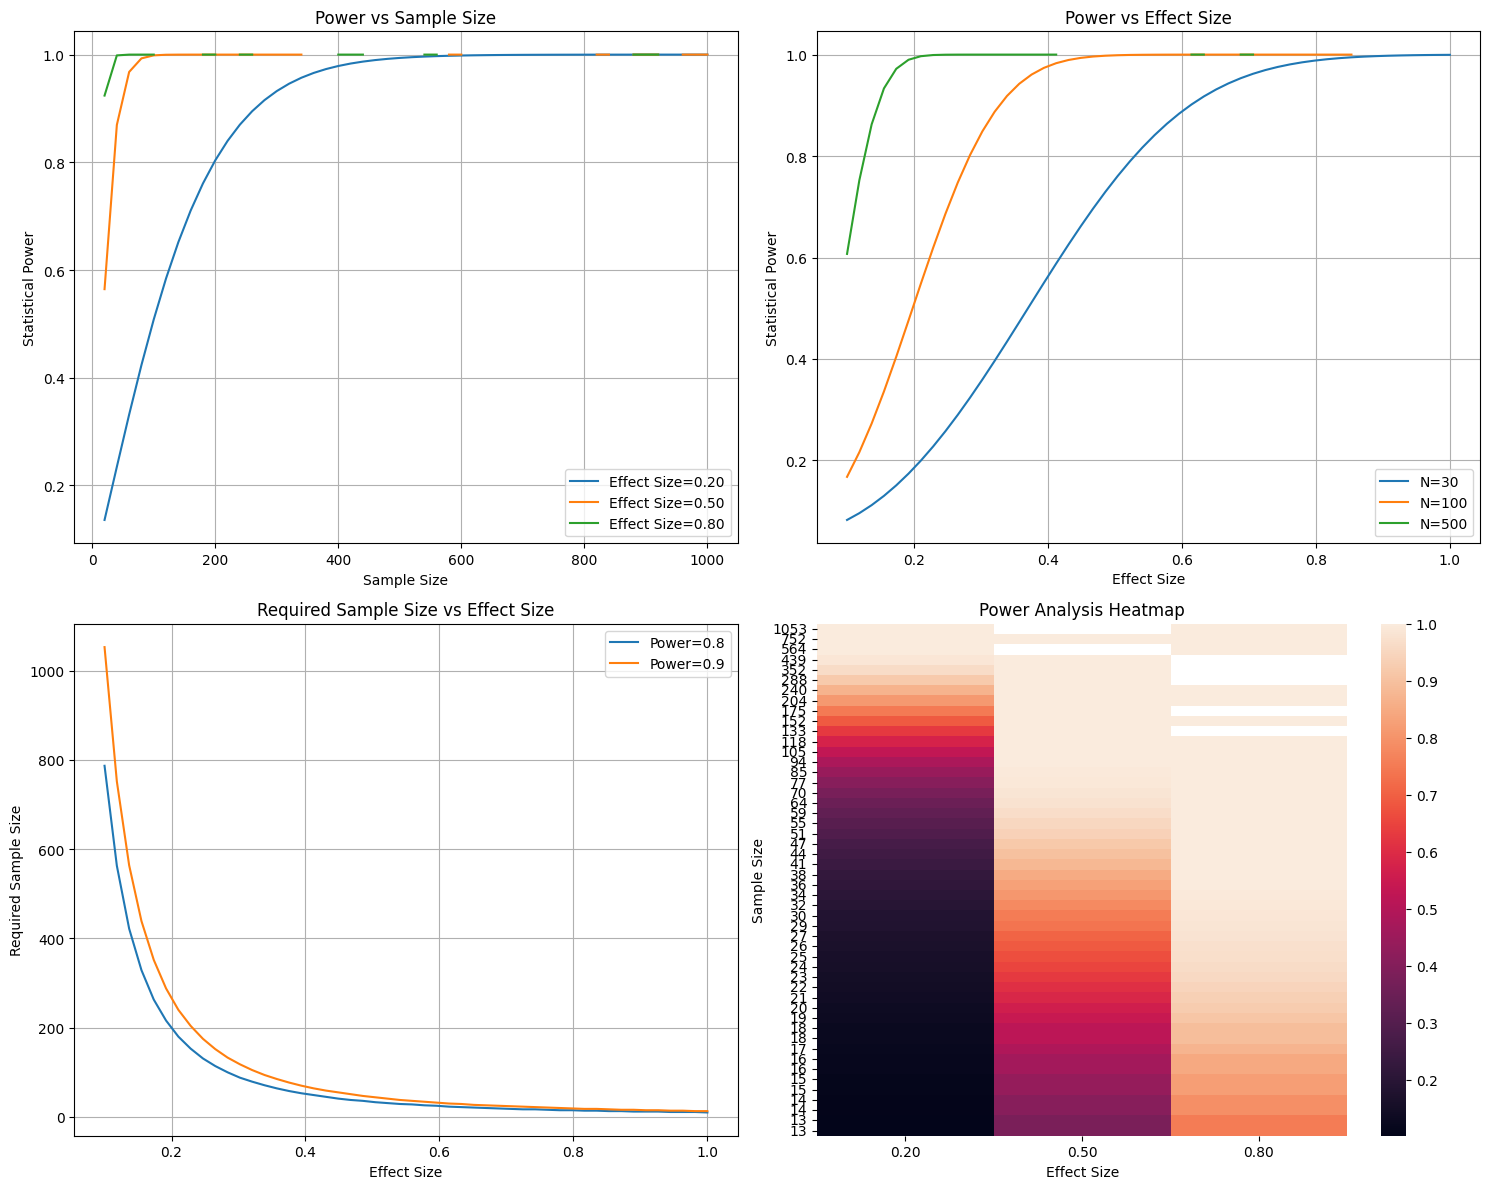

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestPower, GofChisquarePower
import seaborn as sns

class StatisticalPowerAnalyzer:
    def __init__(self, alpha=0.05):
        self.alpha = alpha  # Type I error rate
        
    def calculate_power(self, sample_size, effect_size, test_type='t_test'):
        """
        Calculate statistical power for different test types
        
        Parameters:
        sample_size: int - number of samples
        effect_size: float - Cohen's d for t-test, w for chi-square
        test_type: str - 't_test' or 'chi_square'
        """
        if test_type == 't_test':
            # For t-test
            analysis = TTestPower()
            power = analysis.solve_power(
                effect_size=effect_size,
                nobs=sample_size,
                alpha=self.alpha,
                power=None
            )
        else:
            # For chi-square test
            analysis = GofChisquarePower()
            power = analysis.solve_power(
                effect_size=effect_size,
                nobs=sample_size,
                alpha=self.alpha,
                power=None
            )
            
        return power
    
    def required_sample_size(self, target_power, effect_size, test_type='t_test'):
        """Calculate required sample size for desired power"""
        if test_type == 't_test':
            analysis = TTestPower()
            sample_size = analysis.solve_power(
                effect_size=effect_size,
                power=target_power,
                alpha=self.alpha,
                nobs=None
            )
        else:
            analysis = GofChisquarePower()
            sample_size = analysis.solve_power(
                effect_size=effect_size,
                power=target_power,
                alpha=self.alpha,
                nobs=None
            )
            
        return int(np.ceil(sample_size))
    
    def plot_power_analysis(self, effect_sizes, sample_sizes):
        """Plot power analysis curves"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Power vs Sample Size
        for effect_size in effect_sizes:
            powers = [
                self.calculate_power(n, effect_size)
                for n in sample_sizes
            ]
            axes[0,0].plot(
                sample_sizes,
                powers,
                label=f'Effect Size={effect_size:.2f}'
            )
        
        axes[0,0].set_xlabel('Sample Size')
        axes[0,0].set_ylabel('Statistical Power')
        axes[0,0].set_title('Power vs Sample Size')
        axes[0,0].legend()
        axes[0,0].grid(True)
        
        # Power vs Effect Size
        effect_size_range = np.linspace(0.1, 1.0, 50)
        for n in [30, 100, 500]:
            powers = [
                self.calculate_power(n, es)
                for es in effect_size_range
            ]
            axes[0,1].plot(
                effect_size_range,
                powers,
                label=f'N={n}'
            )
        
        axes[0,1].set_xlabel('Effect Size')
        axes[0,1].set_ylabel('Statistical Power')
        axes[0,1].set_title('Power vs Effect Size')
        axes[0,1].legend()
        axes[0,1].grid(True)
        
        # Required Sample Size
        target_powers = [0.8, 0.9]
        effect_size_range = np.linspace(0.1, 1.0, 50)
        
        for power in target_powers:
            sample_sizes = [
                self.required_sample_size(power, es)
                for es in effect_size_range
            ]
            axes[1,0].plot(
                effect_size_range,
                sample_sizes,
                label=f'Power={power}'
            )
        
        axes[1,0].set_xlabel('Effect Size')
        axes[1,0].set_ylabel('Required Sample Size')
        axes[1,0].set_title('Required Sample Size vs Effect Size')
        axes[1,0].legend()
        axes[1,0].grid(True)
        
        # Power Analysis Heatmap
        power_matrix = np.zeros((len(sample_sizes), len(effect_sizes)))
        for i, n in enumerate(sample_sizes):
            for j, es in enumerate(effect_sizes):
                power_matrix[i,j] = self.calculate_power(n, es)
        
        sns.heatmap(
            power_matrix,
            xticklabels=[f'{es:.2f}' for es in effect_sizes],
            yticklabels=sample_sizes,
            ax=axes[1,1]
        )
        axes[1,1].set_xlabel('Effect Size')
        axes[1,1].set_ylabel('Sample Size')
        axes[1,1].set_title('Power Analysis Heatmap')
        
        plt.tight_layout()
        return fig

def demonstrate_power_analysis():
    """Demonstrate power analysis for credit scoring"""
    analyzer = StatisticalPowerAnalyzer()
    
    # Example scenarios
    sample_sizes = np.linspace(20, 1000, 50).astype(int)
    effect_sizes = [0.2, 0.5, 0.8]  # Small, medium, large
    
    # Plot power analysis
    fig = analyzer.plot_power_analysis(effect_sizes, sample_sizes)
    
    # Calculate power for specific scenarios
    print("Power Analysis Examples:")
    
    scenarios = [
        {'n': 100, 'effect': 0.3, 'desc': 'Small effect, moderate sample'},
        {'n': 500, 'effect': 0.5, 'desc': 'Medium effect, large sample'},
        {'n': 50, 'effect': 0.8, 'desc': 'Large effect, small sample'}
    ]
    
    for scenario in scenarios:
        power = analyzer.calculate_power(
            scenario['n'],
            scenario['effect']
        )
        print(f"\n{scenario['desc']}:")
        print(f"- Sample size: {scenario['n']}")
        print(f"- Effect size: {scenario['effect']:.2f}")
        print(f"- Power: {power:.3f}")
        
        if power < 0.8:
            required_n = analyzer.required_sample_size(0.8, scenario['effect'])
            print(f"- Required sample size for 0.8 power: {required_n}")
    
    return fig

# Run demonstration
fig = demonstrate_power_analysis()
plt.show()


T-Test Example:

Results:
t_statistic: 7.8842
p_value: 0.0000
effect_size: 0.3528
mean_diff: 17.4248

Chi-Square Example:

Results:
chi2_statistic: 40.5132
p_value: 0.0000
degrees_of_freedom: 2.0000
effect_size: 0.2013

Detailed Comparison:
Statistical Test Comparison:

T-Test:

Use Cases:
- Comparing means of continuous variables
- Testing if a treatment has an effect
- Comparing two groups on a continuous measure

Assumptions:
- Normal distribution (for small samples)
- Independent observations
- Equal variances (for Student's t-test)

Example Variables:
- Income
- Credit Score
- Debt-to-Income Ratio

Chi-Square:

Use Cases:
- Testing independence of categorical variables
- Comparing proportions across groups
- Goodness of fit tests

Assumptions:
- Independent observations
- Large enough expected frequencies
- Mutually exclusive categories

Example Variables:
- Employment Status
- Education Level
- Default Status


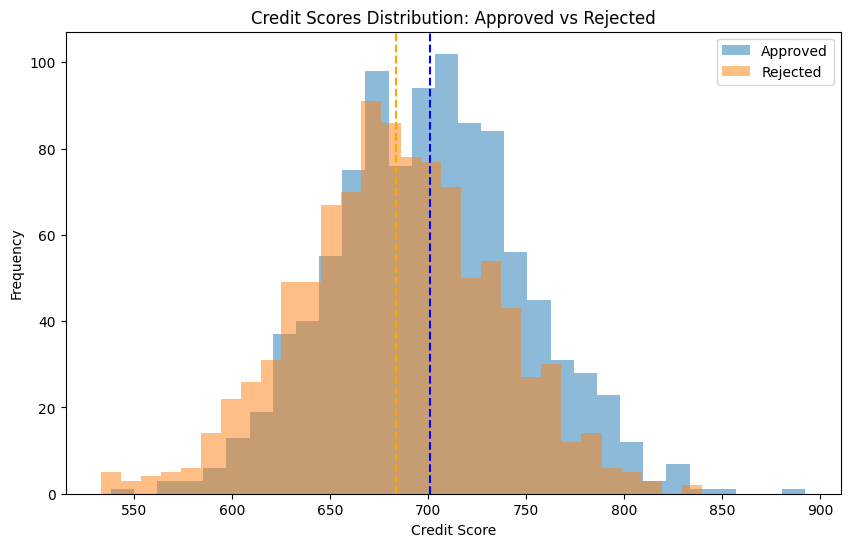

<Figure size 1000x600 with 0 Axes>

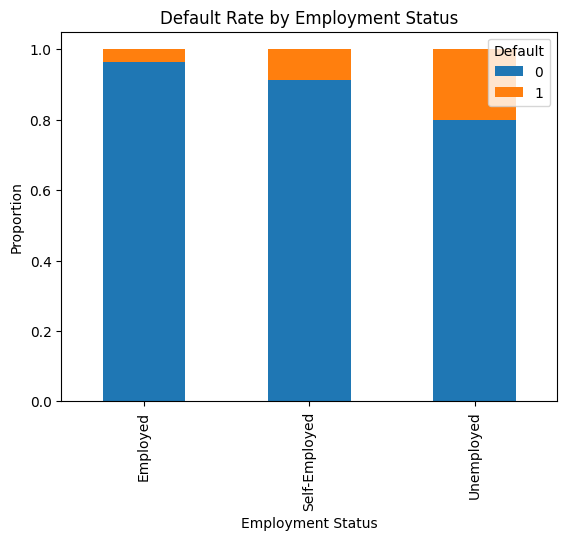

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

class StatisticalTestComparison:
    def __init__(self):
        np.random.seed(42)
        
    def demonstrate_ttest(self, n_samples=1000):
        """
        Demonstrate t-test with credit scoring example
        
        T-test is used for:
        - Comparing means of continuous variables
        - Testing if a continuous variable is different between two groups
        """
        # Create example credit scoring data
        approved_scores = np.random.normal(700, 50, n_samples)  # Credit scores for approved
        rejected_scores = np.random.normal(680, 50, n_samples)  # Credit scores for rejected
        
        # Perform t-test
        t_stat, p_value = stats.ttest_ind(approved_scores, rejected_scores)
        
        # Calculate effect size (Cohen's d)
        effect_size = (np.mean(approved_scores) - np.mean(rejected_scores)) / \
                     np.sqrt((np.var(approved_scores) + np.var(rejected_scores)) / 2)
        
        # Visualize
        plt.figure(figsize=(10, 6))
        plt.hist(approved_scores, alpha=0.5, label='Approved', bins=30)
        plt.hist(rejected_scores, alpha=0.5, label='Rejected', bins=30)
        plt.axvline(np.mean(approved_scores), color='blue', linestyle='--')
        plt.axvline(np.mean(rejected_scores), color='orange', linestyle='--')
        plt.title('Credit Scores Distribution: Approved vs Rejected')
        plt.xlabel('Credit Score')
        plt.ylabel('Frequency')
        plt.legend()
        
        return {
            't_statistic': t_stat,
            'p_value': p_value,
            'effect_size': effect_size,
            'mean_diff': np.mean(approved_scores) - np.mean(rejected_scores)
        }
    
    def demonstrate_chi_square(self, n_samples=1000):
        """
        Demonstrate chi-square test with credit scoring example
        
        Chi-square test is used for:
        - Testing independence of categorical variables
        - Comparing proportions across groups
        """
        # Create example categorical data
        # Employment status vs Default
        employment = np.random.choice(['Employed', 'Self-Employed', 'Unemployed'], 
                                    n_samples, p=[0.7, 0.2, 0.1])
        
        # Generate default based on employment (creating dependency)
        default_prob = {
            'Employed': 0.05,
            'Self-Employed': 0.08,
            'Unemployed': 0.15
        }
        
        default = np.array([
            np.random.choice([0, 1], p=[1-default_prob[emp], default_prob[emp]])
            for emp in employment
        ])
        
        # Create contingency table
        contingency = pd.crosstab(employment, default)
        
        # Perform chi-square test
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
        
        # Calculate Cramer's V (effect size for chi-square)
        n = len(employment)
        min_dim = min(contingency.shape) - 1
        cramer_v = np.sqrt(chi2 / (n * min_dim))
        
        # Visualize
        plt.figure(figsize=(10, 6))
        contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)
        contingency_pct.plot(kind='bar', stacked=True)
        plt.title('Default Rate by Employment Status')
        plt.xlabel('Employment Status')
        plt.ylabel('Proportion')
        plt.legend(title='Default')
        
        return {
            'chi2_statistic': chi2,
            'p_value': p_value,
            'degrees_of_freedom': dof,
            'effect_size': cramer_v,
            'contingency_table': contingency
        }
    
    def compare_tests(self):
        """Compare both tests with practical examples"""
        # Example 1: Income difference between default/non-default (t-test)
        n_samples = 1000
        
        # Generate income data
        income_no_default = np.random.normal(60000, 15000, n_samples)
        income_default = np.random.normal(55000, 15000, n_samples)
        
        # T-test for income
        t_result = stats.ttest_ind(income_no_default, income_default)
        
        # Example 2: Relationship between education and default (chi-square)
        education = np.random.choice(['High School', 'Bachelor', 'Master'], n_samples)
        default = np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        
        # Create contingency table
        contingency = pd.crosstab(education, default)
        chi2_result = stats.chi2_contingency(contingency)
        
        return {
            't_test': {
                'test': 't-test',
                'use_case': 'Comparing income means',
                'statistic': t_result.statistic,
                'p_value': t_result.pvalue,
                'data_type': 'Continuous'
            },
            'chi_square': {
                'test': 'chi-square',
                'use_case': 'Education vs Default',
                'statistic': chi2_result[0],
                'p_value': chi2_result[1],
                'data_type': 'Categorical'
            }
        }

def print_test_comparison():
    """Print detailed comparison of t-test and chi-square"""
    comparison = {
        'T-Test': {
            'Use Cases': [
                'Comparing means of continuous variables',
                'Testing if a treatment has an effect',
                'Comparing two groups on a continuous measure'
            ],
            'Assumptions': [
                'Normal distribution (for small samples)',
                'Independent observations',
                'Equal variances (for Student\'s t-test)'
            ],
            'Example Variables': [
                'Income',
                'Credit Score',
                'Debt-to-Income Ratio'
            ]
        },
        'Chi-Square': {
            'Use Cases': [
                'Testing independence of categorical variables',
                'Comparing proportions across groups',
                'Goodness of fit tests'
            ],
            'Assumptions': [
                'Independent observations',
                'Large enough expected frequencies',
                'Mutually exclusive categories'
            ],
            'Example Variables': [
                'Employment Status',
                'Education Level',
                'Default Status'
            ]
        }
    }
    
    print("Statistical Test Comparison:")
    print("=" * 50)
    
    for test, details in comparison.items():
        print(f"\n{test}:")
        for category, items in details.items():
            print(f"\n{category}:")
            for item in items:
                print(f"- {item}")

# Run demonstrations
test_comparison = StatisticalTestComparison()

print("\nT-Test Example:")
t_test_results = test_comparison.demonstrate_ttest()
print("\nResults:")
for key, value in t_test_results.items():
    print(f"{key}: {value:.4f}")

print("\nChi-Square Example:")
chi_square_results = test_comparison.demonstrate_chi_square()
print("\nResults:")
for key, value in chi_square_results.items():
    if isinstance(value, (float, int)):
        print(f"{key}: {value:.4f}")

print("\nDetailed Comparison:")
print_test_comparison()

plt.show()